In [1]:
!pip install geopandas folium mapclassify contextily scikit-learn


In [5]:
import branca.colormap as cm


✅ Files loaded successfully
✅ CRS set to: EPSG:32644
✅ Baseline created
✅ Transects generated: 1902


/tmp/ipython-input-2812713174.py:98: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shoreline_union = shoreline_gdf.geometry.unary_union
/tmp/ipython-input-2812713174.py:98: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shoreline_union = shoreline_gdf.geometry.unary_union
/tmp/ipython-input-2812713174.py:98: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shoreline_union = shoreline_gdf.geometry.unary_union


✅ Valid transects: 1828


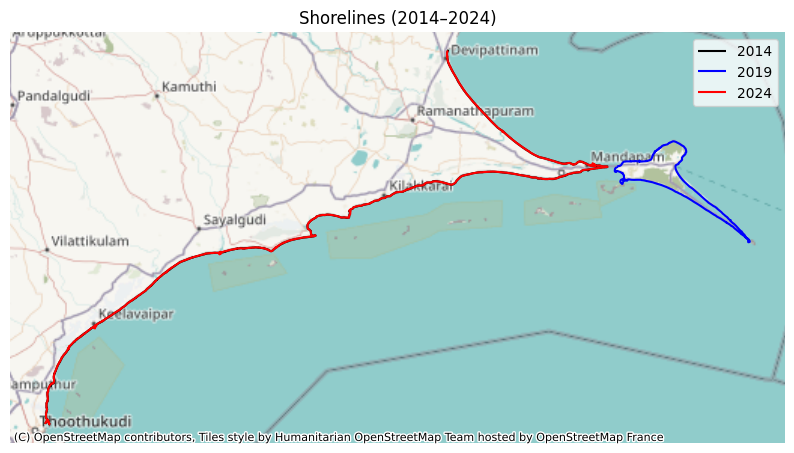

/tmp/ipython-input-2812713174.py:162: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = sh14_wgs.geometry.unary_union.centroid


In [10]:
# ==================================================
# SHORELINE CHANGE ANALYSIS + INTERACTIVE MAP (COLAB)
# 2014 – 2019 – 2024 → Prediction 2050
# ==================================================

# ==================================================
# 0. INSTALL REQUIRED LIBRARIES (RUN ONCE)
# ==================================================
!pip install geopandas contextily folium branca scikit-learn pyproj shapely

# ==================================================
# 1. IMPORTS
# ==================================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import folium
import branca.colormap as cm

from shapely.geometry import LineString, Point
from sklearn.linear_model import LinearRegression

# ==================================================
# 2. READ SHORELINE SHAPEFILES
# ==================================================
sh14 = gpd.read_file("/content/2014.shp")
sh19 = gpd.read_file("/content/2019.shp")
sh24 = gpd.read_file("/content/2024.shp")

print("✅ Files loaded successfully")

# ==================================================
# 3. CRS HANDLING (PROJECTED – METERS)
# ==================================================
if sh14.crs is None or sh14.crs.is_geographic:
    target_crs = "EPSG:32644"   # Change UTM zone if needed
    sh14 = sh14.to_crs(target_crs)
    sh19 = sh19.to_crs(target_crs)
    sh24 = sh24.to_crs(target_crs)
else:
    sh19 = sh19.to_crs(sh14.crs)
    sh24 = sh24.to_crs(sh14.crs)
    target_crs = sh14.crs

print("✅ CRS set to:", target_crs)

# ==================================================
# 4. CREATE BASELINE (50 m OFFSET)
# ==================================================
baseline_lines = []

for geom in sh14.geometry:
    if geom.geom_type == "LineString":
        off = geom.parallel_offset(50, "left", join_style=2)
        if not off.is_empty:
            baseline_lines.append(off)

    elif geom.geom_type == "MultiLineString":
        for g in geom.geoms:
            off = g.parallel_offset(50, "left", join_style=2)
            if not off.is_empty:
                baseline_lines.append(off)

baseline = gpd.GeoSeries(baseline_lines, crs=target_crs).explode(ignore_index=True)
print("✅ Baseline created")

# ==================================================
# 5. TRANSECT GENERATION
# ==================================================
transects = []
spacing = 100
tran_len = 1000

for geom in baseline:
    for d in np.arange(0, geom.length, spacing):
        p = geom.interpolate(d)
        transects.append(
            LineString([
                (p.x, p.y - tran_len/2),
                (p.x, p.y + tran_len/2)
            ])
        )

transects_gdf = gpd.GeoDataFrame(
    {"Transect_ID": range(len(transects))},
    geometry=transects,
    crs=target_crs
)

print("✅ Transects generated:", len(transects_gdf))

# ==================================================
# 6. SHORELINE INTERSECTION DISTANCE
# ==================================================
def shoreline_dist(transect, shoreline_gdf):
    shoreline_union = shoreline_gdf.geometry.unary_union
    inter = transect.intersection(shoreline_union)
    start = Point(transect.coords[0])

    if inter.is_empty:
        return np.nan
    if inter.geom_type == "Point":
        return start.distance(inter)
    if inter.geom_type == "MultiPoint":
        return min(start.distance(p) for p in inter.geoms)

    return np.nan

# ==================================================
# 7. DISTANCES
# ==================================================
transects_gdf["d2014"] = transects_gdf.geometry.apply(lambda g: shoreline_dist(g, sh14))
transects_gdf["d2019"] = transects_gdf.geometry.apply(lambda g: shoreline_dist(g, sh19))
transects_gdf["d2024"] = transects_gdf.geometry.apply(lambda g: shoreline_dist(g, sh24))

# ==================================================
# 8. END POINT RATE (EPR)
# ==================================================
transects_gdf["EPR_14_24"] = (transects_gdf["d2024"] - transects_gdf["d2014"]) / 10
transects_clean = transects_gdf.dropna(subset=["EPR_14_24"]).copy()

print("✅ Valid transects:", len(transects_clean))

# ==================================================
# 9. LINEAR REGRESSION → 2050
# ==================================================
years = np.array([2014, 2019, 2024]).reshape(-1, 1)

def predict_2050(row):
    d = row[["d2014","d2019","d2024"]].astype(float).values # Explicitly cast to float
    if np.isnan(d).any():
        return np.nan
    model = LinearRegression()
    model.fit(years, d.reshape(-1,1))
    return model.predict([[2050]])[0]

transects_clean["Pred_2050"] = transects_clean.apply(predict_2050, axis=1)

# ==================================================
# 10. STATIC MAP CHECK
# ==================================================
fig, ax = plt.subplots(figsize=(10,6))
sh14.to_crs(epsg=3857).plot(ax=ax, color="black", label="2014")
sh19.to_crs(epsg=3857).plot(ax=ax, color="blue", label="2019")
sh24.to_crs(epsg=3857).plot(ax=ax, color="red", label="2024")
ctx.add_basemap(ax)
plt.legend()
plt.title("Shorelines (2014–2024)")
plt.axis("off")
plt.show()

# ==================================================
# 11. INTERACTIVE MAP (FINAL OUTPUT)
# ==================================================
sh14_wgs = sh14.to_crs(epsg=4326)
sh19_wgs = sh19.to_crs(epsg=4326)
sh24_wgs = sh24.to_crs(epsg=4326)
tran_wgs = transects_clean.to_crs(epsg=4326)

center = sh14_wgs.geometry.unary_union.centroid

m = folium.Map(location=[center.y, center.x], zoom_start=11)

# ---- Shorelines ----
folium.GeoJson(sh14_wgs, name="2014", style_function=lambda x: {"color":"black"}).add_to(m)
folium.GeoJson(sh19_wgs, name="2019", style_function=lambda x: {"color":"blue"}).add_to(m)
folium.GeoJson(sh24_wgs, name="2024", style_function=lambda x: {"color":"red"}).add_to(m)

# ---- EPR Legend ----
epr_cmap = cm.LinearColormap(
    ["red","yellow","green"],
    vmin=tran_wgs["EPR_14_24"].min(),
    vmax=tran_wgs["EPR_14_24"].max(),
    caption="EPR 2014–2024 (m/year)"
)

folium.GeoJson(
    tran_wgs,
    name="EPR",
    style_function=lambda f: {
        "color": epr_cmap(f["properties"]["EPR_14_24"])
        if f["properties"]["EPR_14_24"] is not None else "gray",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(fields=["EPR_14_24"])
).add_to(m)

epr_cmap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m

✅ Files loaded successfully
✅ CRS set to: EPSG:32644
✅ Baseline created
✅ Transects generated: 1902


/tmp/ipython-input-2585717990.py:97: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shoreline_union = shoreline_gdf.geometry.unary_union
/tmp/ipython-input-2585717990.py:97: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shoreline_union = shoreline_gdf.geometry.unary_union


✅ Valid transects: 1828


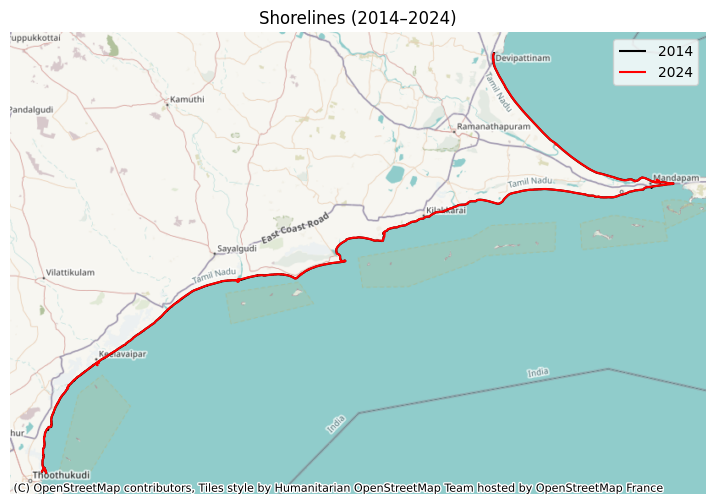

/tmp/ipython-input-2585717990.py:158: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = sh14_wgs.geometry.unary_union.centroid


✅ Interactive map saved: /content/Shoreline_2014_2024_Interactive_Map.html


In [12]:
# ==================================================
# SHORELINE CHANGE ANALYSIS + INTERACTIVE MAP (COLAB)
# 2014 – 2024 → Prediction 2050
# ==================================================

# ==================================================
# 0. INSTALL REQUIRED LIBRARIES (RUN ONCE)
# ==================================================
!pip install geopandas contextily folium branca scikit-learn pyproj shapely

# ==================================================
# 1. IMPORTS
# ==================================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import folium
import branca.colormap as cm

from shapely.geometry import LineString, Point
from sklearn.linear_model import LinearRegression

# ==================================================
# 2. READ SHORELINE SHAPEFILES
# ==================================================
sh14 = gpd.read_file("/content/2014.shp")
sh24 = gpd.read_file("/content/2024.shp")

print("✅ Files loaded successfully")

# ==================================================
# 3. CRS HANDLING (PROJECTED – METERS)
# ==================================================
if sh14.crs is None or sh14.crs.is_geographic:
    target_crs = "EPSG:32644"   # Change UTM zone if needed
    sh14 = sh14.to_crs(target_crs)
    sh24 = sh24.to_crs(target_crs)
else:
    sh24 = sh24.to_crs(sh14.crs)
    target_crs = sh14.crs

print("✅ CRS set to:", target_crs)

# ==================================================
# 4. CREATE BASELINE (50 m OFFSET)
# ==================================================
baseline_lines = []

for geom in sh14.geometry:
    if geom.geom_type == "LineString":
        off = geom.parallel_offset(50, "left", join_style=2)
        if not off.is_empty:
            baseline_lines.append(off)
    elif geom.geom_type == "MultiLineString":
        for g in geom.geoms:
            off = g.parallel_offset(50, "left", join_style=2)
            if not off.is_empty:
                baseline_lines.append(off)

baseline = gpd.GeoSeries(
    baseline_lines, crs=target_crs
).explode(ignore_index=True)

print("✅ Baseline created")

# ==================================================
# 5. TRANSECT GENERATION
# ==================================================
transects = []
spacing = 100      # meters
tran_len = 1000    # total transect length

for geom in baseline:
    for d in np.arange(0, geom.length, spacing):
        p = geom.interpolate(d)
        transects.append(
            LineString([
                (p.x, p.y - tran_len/2),
                (p.x, p.y + tran_len/2)
            ])
        )

transects_gdf = gpd.GeoDataFrame(
    {"Transect_ID": range(len(transects))},
    geometry=transects,
    crs=target_crs
)

print("✅ Transects generated:", len(transects_gdf))

# ==================================================
# 6. SHORELINE INTERSECTION DISTANCE
# ==================================================
def shoreline_dist(transect, shoreline_gdf):
    shoreline_union = shoreline_gdf.geometry.unary_union
    inter = transect.intersection(shoreline_union)
    start = Point(transect.coords[0])

    if inter.is_empty:
        return np.nan
    if inter.geom_type == "Point":
        return start.distance(inter)
    if inter.geom_type == "MultiPoint":
        return min(start.distance(p) for p in inter.geoms)
    return np.nan

# ==================================================
# 7. DISTANCES
# ==================================================
transects_gdf["d2014"] = transects_gdf.geometry.apply(lambda g: shoreline_dist(g, sh14))
transects_gdf["d2024"] = transects_gdf.geometry.apply(lambda g: shoreline_dist(g, sh24))

# ==================================================
# 8. END POINT RATE (EPR)
# ==================================================
transects_gdf["EPR_14_24"] = (transects_gdf["d2024"] - transects_gdf["d2014"]) / 10
transects_clean = transects_gdf.dropna(subset=["EPR_14_24"]).copy()

print("✅ Valid transects:", len(transects_clean))

# ==================================================
# 9. LINEAR REGRESSION → 2050
# ==================================================
years = np.array([2014, 2024]).reshape(-1,1)

def predict_2050(row):
    d = row[["d2014","d2024"]].values.astype(float)
    if np.isnan(d).any():
        return np.nan
    model = LinearRegression()
    model.fit(years, d.reshape(-1,1))
    # Ensure a scalar float is returned, not a 1D numpy array
    return model.predict([[2050]])[0][0]

transects_clean["Pred_2050"] = transects_clean.apply(predict_2050, axis=1)

# ==================================================
# 10. STATIC MAP CHECK
# ==================================================
fig, ax = plt.subplots(figsize=(10,6))
sh14.to_crs(epsg=3857).plot(ax=ax, color="black", label="2014")
sh24.to_crs(epsg=3857).plot(ax=ax, color="red", label="2024")
ctx.add_basemap(ax)
plt.legend()
plt.title("Shorelines (2014–2024)")
plt.axis("off")
plt.show()

# ==================================================
# 11. INTERACTIVE MAP
# ==================================================
sh14_wgs = sh14.to_crs(epsg=4326)
sh24_wgs = sh24.to_crs(epsg=4326)
tran_wgs = transects_clean.to_crs(epsg=4326)

center = sh14_wgs.geometry.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=11)

# ---- Shorelines ----
folium.GeoJson(sh14_wgs, name="2014", style_function=lambda x: {"color":"black"}).add_to(m)
folium.GeoJson(sh24_wgs, name="2024", style_function=lambda x: {"color":"red"}).add_to(m)

# ---- EPR Legend ----
epr_cmap = cm.LinearColormap(
    ["red","yellow","green"],
    vmin=tran_wgs["EPR_14_24"].min(),
    vmax=tran_wgs["EPR_14_24"].max(),
    caption="EPR 2014–2024 (m/year)"
)

folium.GeoJson(
    tran_wgs,
    name="EPR",
    style_function=lambda f: {
        "color": epr_cmap(f["properties"]["EPR_14_24"])
        if f["properties"]["EPR_14_24"] is not None else "gray",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(fields=["EPR_14_24"], aliases=["EPR (m/year):"])
).add_to(m)

epr_cmap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ==================================================
# 12. SAVE INTERACTIVE MAP AS HTML
# ==================================================
m.save("/content/Shoreline_2014_2024_Interactive_Map.html")
print("✅ Interactive map saved: /content/Shoreline_2014_2024_Interactive_Map.html")

# Display map in Colab
m